In [1]:
!pip install -q git+https://github.com/RayenSansa03/aeroguard.git@main --force-reinstall --no-deps
!nvidia-smi --query-gpu=name --format=csv

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
name
Tesla T4


In [2]:
from google.colab import drive
drive.mount("/content/drive")

import numpy as np
import pandas as pd
from aeroguard.donnees_ml import preparer_xy_famille

DOSSIER = "/content/drive/MyDrive/aeroguard"
vols = pd.read_parquet(f"{DOSSIER}/data/processed/vols_ncmapss.parquet")

# Combien de MOTEURS par famille et par groupe ?
vols.groupby(["famille", "groupe"])["moteur"].nunique().unstack(fill_value=0)

Mounted at /content/drive


groupe,test,train,val
famille,,,
HPC,4,5,1
HPT,4,8,1
HPT+LPT,9,6,3
LPC+HPC,4,5,1
LPT,4,8,1
fan,4,5,1
mixte,10,12,3


In [3]:
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

X_train, fam_train = preparer_xy_famille(vols, "train")
X_val, fam_val = preparer_xy_famille(vols, "val")

absentes = set(fam_val) - set(fam_train)
assert not absentes, f"Familles de val jamais vues au train : {absentes}"

encodeur = LabelEncoder().fit(fam_train)          # "Fan" → 0, "HPT" → 1, ...
y_train = encodeur.transform(fam_train)
y_val = encodeur.transform(fam_val)
familles = list(encodeur.classes_)
poids = compute_sample_weight("balanced", y_train)  # les familles rares comptent autant

print("Familles :", familles)
print("Vols usés : train", len(X_train), "| val", len(X_val))
print(fam_train.value_counts())

Familles : ['HPC', 'HPT', 'HPT+LPT', 'LPC+HPC', 'LPT', 'fan', 'mixte']
Vols usés : train 2620 | val 575
famille
HPT        529
mixte      515
LPT        382
fan        340
HPT+LPT    306
HPC        281
LPC+HPC    267
Name: count, dtype: int64


In [4]:
import time
from aeroguard.modeles import creer_xgboost

xgb_diag = creer_xgboost(device="cuda", objective="multi:softprob", eval_metric="mlogloss")
debut = time.perf_counter()
xgb_diag.fit(X_train, y_train, sample_weight=poids,
             eval_set=[(X_val, y_val)], verbose=100)
print(f"Temps : {time.perf_counter() - debut:.1f} s | arbres gardés : {xgb_diag.best_iteration + 1}")

[0]	validation_0-mlogloss:1.87961
[100]	validation_0-mlogloss:0.69083
[200]	validation_0-mlogloss:0.61853
[298]	validation_0-mlogloss:0.60014
Temps : 3.5 s | arbres gardés : 249


/usr/local/lib/python3.13/dist-packages/xgboost/core.py:569: UserWarning: [15:01:19] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Exactitude : 0.73
F1 macro   : 0.721

              precision    recall  f1-score   support

         HPC       0.63      0.46      0.53        57
         HPT       0.89      1.00      0.94        64
     HPT+LPT       0.73      0.66      0.69       138
     LPC+HPC       0.57      0.79      0.66        67
         LPT       0.39      0.40      0.40        67
         fan       1.00      1.00      1.00        67
       mixte       0.84      0.80      0.82       115

    accuracy                           0.73       575
   macro avg       0.72      0.73      0.72       575
weighted avg       0.74      0.73      0.73       575



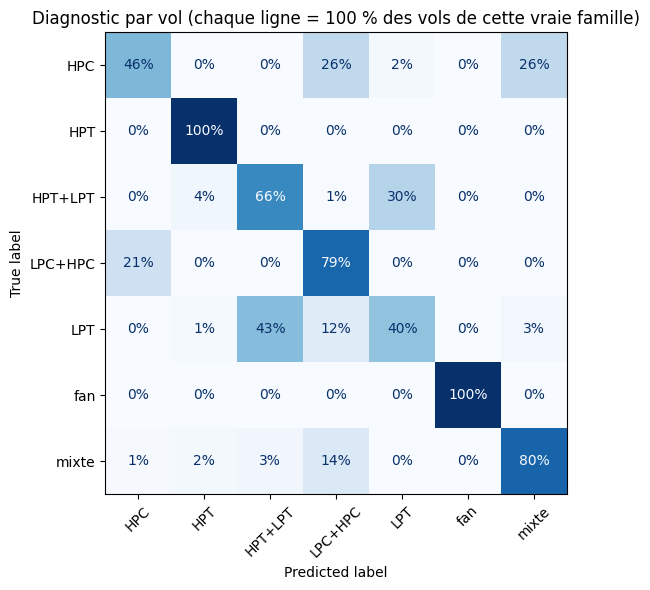

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             classification_report, f1_score)

pred_val = xgb_diag.predict(X_val)
print("Exactitude :", round(accuracy_score(y_val, pred_val), 3))
print("F1 macro   :", round(f1_score(y_val, pred_val, average="macro"), 3))
print()
print(classification_report(y_val, pred_val, labels=range(len(familles)),
                            target_names=familles, zero_division=0))

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_val, pred_val, labels=range(len(familles)), display_labels=familles,
    normalize="true", values_format=".0%", cmap="Blues", ax=ax, colorbar=False)
ax.set_title("Diagnostic par vol (chaque ligne = 100 % des vols de cette vraie famille)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

logi_diag = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000))
logi_diag.fit(X_train, y_train, logisticregression__sample_weight=poids)
pred_logi = logi_diag.predict(X_val)

pd.DataFrame({
    "logistique": [accuracy_score(y_val, pred_logi), f1_score(y_val, pred_logi, average="macro")],
    "xgboost": [accuracy_score(y_val, pred_val), f1_score(y_val, pred_val, average="macro")],
}, index=["exactitude", "f1_macro"]).round(3)

,logistique,xgboost
exactitude,0.835,0.730
f1_macro,0.829,0.721


In [7]:
from aeroguard.metier import diagnostic_par_moteur

moteurs_val = vols.loc[X_val.index, "moteur"]
verite = vols.loc[X_val.index].groupby("moteur")["famille"].first()
diag_xgb = diagnostic_par_moteur(moteurs_val, encodeur.inverse_transform(pred_val))
diag_logi = diagnostic_par_moteur(moteurs_val, encodeur.inverse_transform(pred_logi))

par_moteur = pd.DataFrame({"vraie_famille": verite, "xgboost": diag_xgb, "logistique": diag_logi})
par_moteur["xgb_ok"] = par_moteur["xgboost"] == par_moteur["vraie_famille"]
par_moteur["logi_ok"] = par_moteur["logistique"] == par_moteur["vraie_famille"]
print("Moteurs bien diagnostiqués — XGBoost :", par_moteur["xgb_ok"].sum(), "/", len(par_moteur),
      "| logistique :", par_moteur["logi_ok"].sum(), "/", len(par_moteur))
par_moteur

Moteurs bien diagnostiqués — XGBoost : 9 / 11 | logistique : 11 / 11


,vraie_famille,xgboost,logistique,xgb_ok,logi_ok
moteur,,,,,
DS01_1,HPT,HPT,HPT,True,True
DS02_18,HPT+LPT,HPT+LPT,HPT+LPT,True,True
DS03_4,HPT+LPT,HPT+LPT,HPT+LPT,True,True
DS03_6,HPT+LPT,LPT,HPT+LPT,False,True
DS04_6,fan,fan,fan,True,True
DS05_1,HPC,HPC,HPC,True,True
DS06_5,LPC+HPC,LPC+HPC,LPC+HPC,True,True
DS07_2,LPT,HPT+LPT,LPT,False,True
DS08a_1,mixte,mixte,mixte,True,True


In [8]:
proba = xgb_diag.predict_proba(X_val)
i = len(X_val) - 1                                   # le dernier vol usé de la validation
avis = pd.Series(proba[i], index=familles).sort_values(ascending=False)
print("Moteur :", moteurs_val.iloc[i], "| vraie famille :", fam_val.iloc[i])
print((avis * 100).round(1).astype(str) + " %")

Moteur : DS08c_5 | vraie famille : mixte
mixte      99.5 %
HPT+LPT     0.2 %
LPC+HPC     0.1 %
HPC         0.1 %
HPT         0.1 %
LPT         0.1 %
fan         0.0 %
dtype: object


In [10]:
import json
import joblib
from aeroguard.evaluation import ajouter_au_leaderboard

xgb_diag.save_model(f"{DOSSIER}/models/xgb_diagnostic_v3.json")
joblib.dump(logi_diag, f"{DOSSIER}/models/logistique_diagnostic_v3.joblib")
with open(f"{DOSSIER}/models/familles_v3.json", "w") as f:
    json.dump(familles, f)

chemin = f"{DOSSIER}/results/leaderboard_diagnostic.csv"
for nom, pred, ok in [("logistique", pred_logi, par_moteur["logi_ok"]),
                      ("xgboost_gpu", pred_val, par_moteur["xgb_ok"])]:
    ajouter_au_leaderboard(chemin, nom, {
        "exactitude": accuracy_score(y_val, pred),
        "f1_macro": f1_score(y_val, pred, average="macro"),
        "moteurs_bien_diagnostiques": int(ok.sum()),
        "moteurs": len(ok),
    })
pd.read_csv(chemin)

,modele,exactitude,f1_macro,moteurs_bien_diagnostiques,moteurs
0,logistique,0.834783,0.829293,11,11
1,xgboost_gpu,0.730435,0.721062,9,11
